# 03 Model Training

This notebook trains a classification model to predict whether a dealership customer lead is likely to convert into a vehicle purchase.

The model uses customer, enquiry and sales activity features such as lead source, vehicle type, finance enquiry, trade-in interest, test drive completion, quote status, response time and follow-up count.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

## Load Dataset

In [2]:
df = pd.read_csv("../data/raw/dealership_leads.csv")

df.head()

,lead_id,lead_source,customer_age_group,customer_location,vehicle_type,new_or_used,budget_range,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,converted
0,L0001,Walk-in,35-44,Nearby Suburb,Hatchback,Used,Medium,1,0,1,0,0,18.8,5,38,1
1,L0002,Social Media,35-44,Nearby Suburb,Sedan,New,High,0,0,0,1,1,4.0,2,20,1
2,L0003,Carsales,18-24,Local,SUV,Demo,Low,1,1,0,0,0,5.5,2,29,0
3,L0004,Carsales,25-34,Nearby Suburb,SUV,Used,Low,0,0,1,0,0,2.9,2,6,0
4,L0005,Website,25-34,Nearby Suburb,Sedan,New,Medium,1,1,0,0,0,7.2,2,9,0


In [3]:
df.shape

(1500, 16)

In [4]:
df["converted"].value_counts(normalize=True)

converted
0    0.657333
1    0.342667
Name: proportion, dtype: float64

## Define Features and Target

The target variable is `converted`, which indicates whether the lead resulted in a vehicle purchase.

In [5]:
target = "converted"

features = [
    "lead_source",
    "customer_age_group",
    "customer_location",
    "vehicle_type",
    "new_or_used",
    "budget_range",
    "finance_enquiry",
    "trade_in",
    "test_drive_completed",
    "quote_provided",
    "previous_customer",
    "response_time_hours",
    "follow_up_count",
    "days_since_enquiry"
]

X = df[features]
y = df[target]

In [6]:
categorical_features = [
    "lead_source",
    "customer_age_group",
    "customer_location",
    "vehicle_type",
    "new_or_used",
    "budget_range"
]

numeric_features = [
    "finance_enquiry",
    "trade_in",
    "test_drive_completed",
    "quote_provided",
    "previous_customer",
    "response_time_hours",
    "follow_up_count",
    "days_since_enquiry"
]

## Train-Test Split

The data is split into training and testing sets so the model can be evaluated on unseen leads.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((1125, 14), (375, 14))

## Preprocessing Pipeline

Categorical variables are one-hot encoded, while numeric variables are passed through unchanged.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

## Train Baseline Models

Three classification models are tested:

- Logistic Regression
- Random Forest
- XGBoost, if available

The goal is to compare model performance and choose a practical model for lead scoring.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

if xgboost_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss"
    )

In [10]:
results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })
    
    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.760000,0.715909,0.492188,0.583333,0.816549
2,XGBoost,0.746667,0.681319,0.484375,0.566210,0.774545
1,Random Forest,0.717333,0.696429,0.304688,0.423913,0.764961


## Best Model Selection

ROC-AUC is used as the primary comparison metric because the model needs to rank leads by likelihood of conversion, not just predict a yes/no outcome.

In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_model_name

'Logistic Regression'

In [12]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       247
           1       0.72      0.49      0.58       128

    accuracy                           0.76       375
   macro avg       0.74      0.70      0.71       375
weighted avg       0.75      0.76      0.75       375



In [13]:
confusion_matrix(y_test, y_pred)

array([[222,  25],
       [ 65,  63]], dtype=int64)

## Feature Importance

Feature importance helps explain which factors are most influential in predicting lead conversion.

In [14]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_[0])
else:
    importances = None

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
27,num__test_drive_completed,1.308601
28,num__quote_provided,0.754098
25,num__finance_enquiry,0.724623
3,cat__lead_source_Social Media,0.550481
29,num__previous_customer,0.544269
26,num__trade_in,0.455572
4,cat__lead_source_Walk-in,0.412722
23,cat__budget_range_Low,0.379679
2,cat__lead_source_Referral,0.330710
22,cat__budget_range_High,0.316203


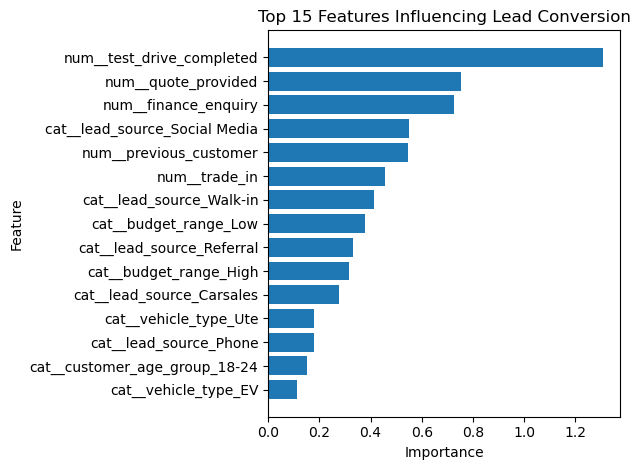

In [15]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(by="importance")

plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Features Influencing Lead Conversion")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Save Test Predictions

The model outputs conversion probabilities that can later be used for lead scoring.

In [16]:
test_predictions = X_test.copy()
test_predictions["actual_converted"] = y_test.values
test_predictions["predicted_converted"] = y_pred
test_predictions["conversion_probability"] = y_proba

test_predictions.head()

,lead_source,customer_age_group,customer_location,vehicle_type,new_or_used,budget_range,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,actual_converted,predicted_converted,conversion_probability
746,Walk-in,18-24,Nearby Suburb,Ute,Used,Low,1,0,0,0,0,23.2,2,15,0,0,0.079043
331,Carsales,35-44,Nearby Suburb,Ute,Used,Medium,1,0,1,0,1,23.0,3,20,0,0,0.332412
593,Walk-in,35-44,Nearby Suburb,SUV,Demo,High,0,0,0,1,0,6.7,2,19,0,0,0.362910
316,Walk-in,25-34,Nearby Suburb,EV,Used,Low,1,1,0,0,0,20.5,3,9,0,0,0.228900
1425,Social Media,55+,Local,Hatchback,New,Medium,1,1,1,0,0,7.4,4,17,1,1,0.542355


In [17]:
output_path = "../data/processed/model_test_predictions.csv"

test_predictions.to_csv(output_path, index=False)

print(f"Predictions saved to: {output_path}")

Predictions saved to: ../data/processed/model_test_predictions.csv


## Key Findings

- The model predicts lead conversion using a combination of customer profile, enquiry source and sales activity features.
- Buying-intent signals such as test drive completion, quote provided, finance enquiry and trade-in interest are expected to be strong predictors.
- ROC-AUC is useful because the dealership needs to rank leads by priority rather than only classify them as converted or not converted.
- The output probabilities can be converted into high, medium and low priority lead segments in the next notebook.